# Moving Animal Attention Task Stimuli

Demos for the five attention-style tasks adapted to the RPL moving animal sprites on a configurable canvas. The notebook samples raw stimuli and labels only; it does not assume a decoder or attention architecture.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from harpl.data import MovingAnimalAttentionDataset

DATA_DIR = PROJECT_ROOT / "datasets"
BASE_SEED = 2026

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Shared configuration

The default noise level is the moving-animal training level (`0.1`) for every task except object recognition, where the default is higher (`0.2`) to force use of attention under severe noise and static occlusion. Sprites pass through each other; only wall reflections are simulated.

In [3]:
COMMON_KWARGS = dict(
    data_dir=DATA_DIR,
    output_size=(64, 64),
    seq_len=32,
    num_sequences=16,
    noise_type="gaussian",
    training_noise_level=0.1,
    object_recognition_noise_level=0.2,
    noise_on_top=True,
    freeze_noise=False,
    cue_frames=6,
    crowd_size=3,
    num_distractors=2,
    fixation_size = 4,
    max_sprites=8
)

In [4]:
def frame_to_image(video, frame_idx):
    image = video[frame_idx].detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(image, 0.0, 1.0)


def class_name(dataset, class_id):
    class_id = int(class_id)
    if class_id < 0:
        return "none"
    return f"{class_id}: {dataset.class_names[class_id]}"


def show_sample(dataset, index=0, frame_ids=(0, 5, 10, 20, 31), title=None):
    video, labels = dataset[index]
    target = int(labels["target_class"])
    prompt = int(labels["prompt_class"])
    task = labels["task"]
    mode = labels["popout_mode"]
    noise = float(labels["noise_level"])

    target_matches = torch.nonzero(labels["is_target"] & labels["object_mask"]).flatten()
    target_obj = int(target_matches[0])
    object_count = int(labels["object_count"])

    print(f"task={task}, popout_mode={mode}, noise={noise:.2f}")
    print(f"target={class_name(dataset, target)}, prompt={class_name(dataset, prompt)}, target_object={target_obj}")
    print("objects:", [class_name(dataset, c) for c in labels["object_class"][:object_count]])

    fig, axes = plt.subplots(1, len(frame_ids) + 1, figsize=(2.1 * (len(frame_ids) + 1), 2.3))
    for ax, frame_idx in zip(axes[:-1], frame_ids):
        ax.imshow(frame_to_image(video, frame_idx))
        ax.set_title(f"t={frame_idx}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    path_ax = axes[-1]
    positions = labels["positions"].detach().cpu().numpy()
    visible = labels["visible"].detach().cpu().numpy()
    for obj_idx in range(object_count):
        valid = visible[:, obj_idx]
        xy = positions[:, obj_idx]
        line_kwargs = dict(lw=2.2 if obj_idx == target_obj else 1.0, alpha=0.95 if obj_idx == target_obj else 0.45)
        path_ax.plot(xy[valid, 0], xy[valid, 1], marker="o", markersize=2, **line_kwargs)
    _, _, height, width = video.shape
    path_ax.set_xlim(0, width)
    path_ax.set_ylim(height, 0)
    path_ax.set_aspect("equal")
    path_ax.set_title("visible paths", fontsize=9)
    path_ax.set_xticks([])
    path_ax.set_yticks([])

    fig.suptitle(title or task, y=1.02, fontsize=12)
    fig.tight_layout()
    return video, labels

## 1. Object recognition

No prompt. One moving sprite is shown under high noise and fixed foreground occluders. The target class is repeated at every timepoint.

task=object_recognition, popout_mode=none, noise=0.20
target=6: sprite_6, prompt=none, target_object=0
objects: ['6: sprite_6']


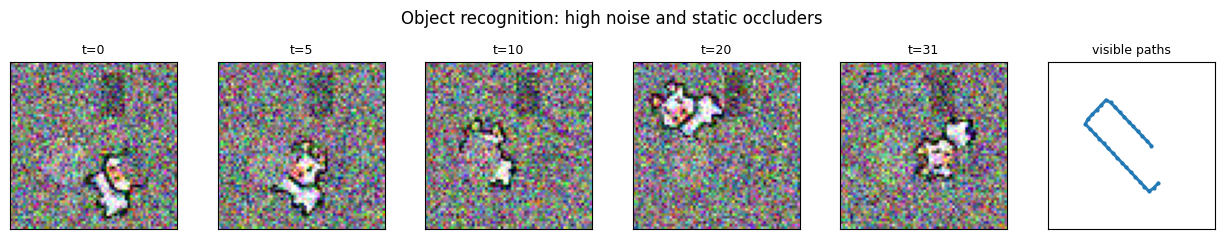

In [5]:
object_recognition_ds = MovingAnimalAttentionDataset(
    **COMMON_KWARGS,
    task="object_recognition",
    seed=BASE_SEED,
    occluder_count=3,
)
_ = show_sample(object_recognition_ds, title="Object recognition: high noise and static occluders")

## 2. Pop-out

No prompt. The target is the class of the odd-one-out sprite. The demo shows class-, rotation-, and velocity-defined pop-out cases.

task=popout, popout_mode=class, noise=0.10
target=3: sprite_3, prompt=none, target_object=0
objects: ['3: sprite_3', '6: sprite_6', '6: sprite_6']
task=popout, popout_mode=rotation, noise=0.10
target=5: sprite_5, prompt=none, target_object=2
objects: ['2: sprite_2', '6: sprite_6', '5: sprite_5']
task=popout, popout_mode=velocity, noise=0.10
target=7: sprite_7, prompt=none, target_object=2
objects: ['2: sprite_2', '3: sprite_3', '7: sprite_7']


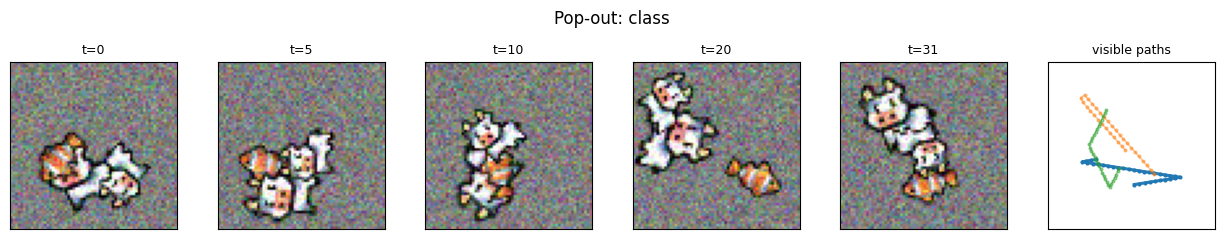

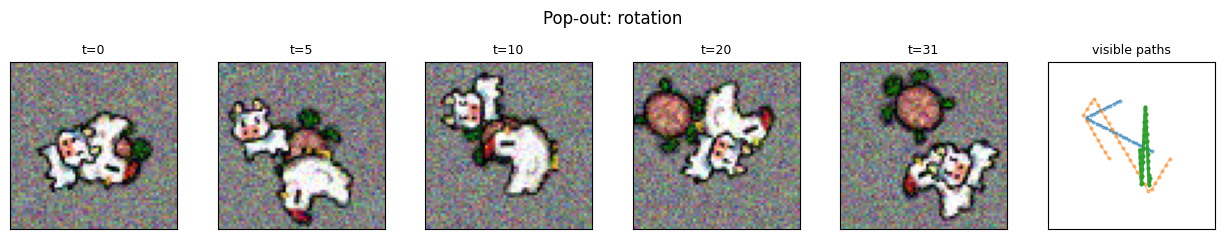

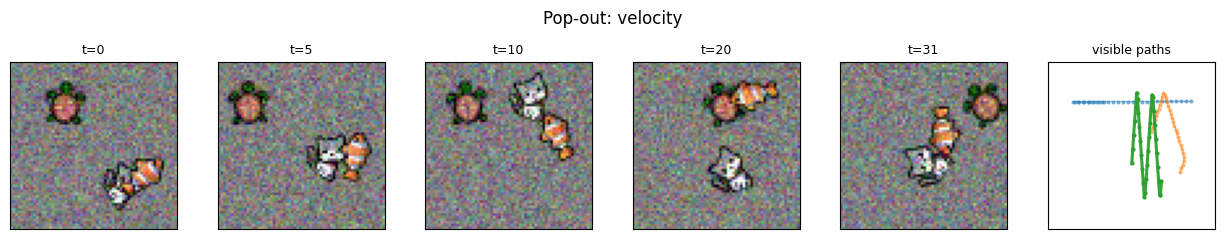

In [6]:
for i, mode in enumerate(["class", "rotation", "velocity"]):
    popout_ds = MovingAnimalAttentionDataset(
        **COMMON_KWARGS,
        task="popout",
        popout_mode=mode,
        velocity_popout_kind="fast",
        seed=BASE_SEED + 10 + i,
    )
    _ = show_sample(popout_ds, title=f"Pop-out: {mode}")

## 3. Tracking

No prompt. The target sprite appears alone for the cue period, then distractors are revealed at the canvas borders and can occlude it. The training target remains the initially cued class.

task=tracking, popout_mode=none, noise=0.10
target=7: sprite_7, prompt=none, target_object=0
objects: ['7: sprite_7', '4: sprite_4', '1: sprite_1']


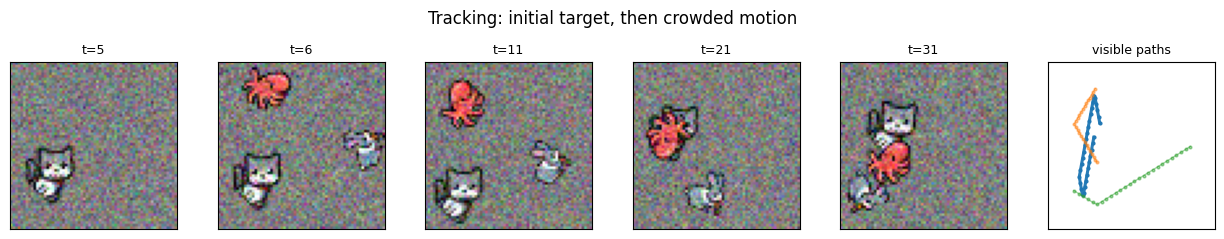

In [7]:
tracking_ds = MovingAnimalAttentionDataset(
    **COMMON_KWARGS,
    task="tracking",
    seed=BASE_SEED + 301,
)
_ = show_sample(tracking_ds, frame_ids=(5, 6, 11, 21, 31), title="Tracking: initial target, then crowded motion")

## 4. Top-down search

The prompt is the class to find. The dense target is the same class at all timepoints.

task=top_down_search, popout_mode=none, noise=0.10
target=7: sprite_7, prompt=7: sprite_7, target_object=2
objects: ['5: sprite_5', '0: sprite_0', '7: sprite_7']


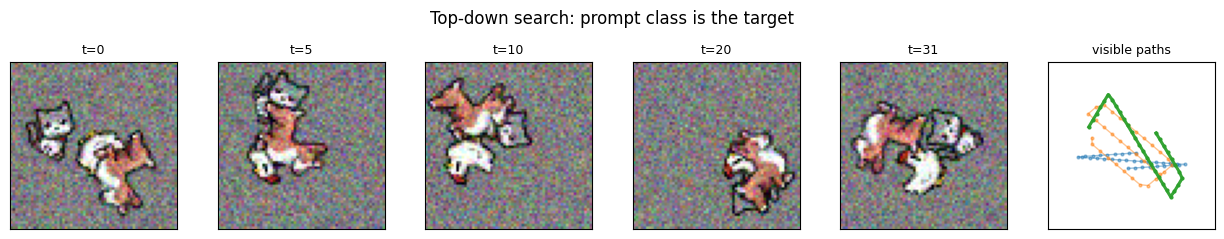

In [8]:
search_ds = MovingAnimalAttentionDataset(
    **COMMON_KWARGS,
    task="top_down_search",
    seed=BASE_SEED + 40,
)
_ = show_sample(search_ds, title="Top-down search: prompt class is the target")

## 5. Perceptual grouping

No prompt. The first cue frames show only a fixation square tracing the future target's center of mass. The first reveal frame uses the same target center as the last fixation-only frame, distractors are revealed at the canvas borders, and the target object is rendered top-most.

task=perceptual_grouping, popout_mode=none, noise=0.10
target=4: sprite_4, prompt=none, target_object=0
objects: ['4: sprite_4', '7: sprite_7', '1: sprite_1']


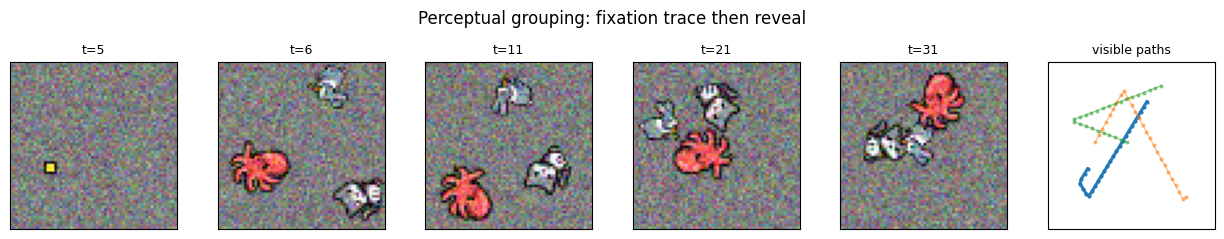

In [9]:
grouping_ds = MovingAnimalAttentionDataset(
    **COMMON_KWARGS,
    task="perceptual_grouping",
    seed=BASE_SEED + 550,
)
_ = show_sample(grouping_ds, frame_ids=(5, 6, 11, 21, 31), title="Perceptual grouping: fixation trace then reveal")

## Label contract

The key labels for decoder training are `target_class_dense` and `prompt_class_dense`. No-prompt tasks use `-1` in the prompt fields. Object metadata is padded to a fixed `max_objects` length for batching.

In [15]:
video, labels = search_ds[0]
print(video.shape)
# print(labels)

for key in [
    "task",
    "target_class",
    "target_class_dense",
    "prompt_class",
    "prompt_class_dense",
    "object_class",
    "object_mask",
    "is_target",
    "positions",
    "visible",
]:
    value = labels[key]
    shape = tuple(value.shape) if hasattr(value, "shape") else "scalar"
    print(f"{key:20s}", shape, value if shape == "scalar" else "")

torch.Size([32, 3, 64, 64])
task                 scalar top_down_search
target_class         () 
target_class_dense   (32,) 
prompt_class         () 
prompt_class_dense   (32,) 
object_class         (3,) 
object_mask          (3,) 
is_target            (3,) 
positions            (32, 3, 2) 
visible              (32, 3) 
